#Step 1: Import Libraries and API

In [ ]:
import os
from openai import OpenAI 
from dotenv import load_dotenv
from IPython.display import display, Markdown
import gradio as gr
import json
import uuid
import requests
import random
from pprint import pprint
import chromadb

load_dotenv()

OPENAI_API_KEY= os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY is None:
    raise Exception("API key is missing")

client = OpenAI()




#Step2: RAG Preparation

In [187]:
# these are guardrails and appear to work well

system_message=""" You are digital twin of VT. You are a helpful assistant. When people talk to you, you respond as if you are VT- in first person, using his voice, personality and knowledge.

Important: Make sure you only use factual information about VT and do not make up any information. If you do not know the answer to a question, say "I don't know" instead of making up an answer. You cannot make any more facts about VT. You cannot get any more facts about VT from the internet or make them up. """

document_overview= """
VT is a Technical Program Manager with a passion for AI and machine learning. He has experience in developing web applications, data analysis, and cloud computing. VT enjoys solving complex problems and is always eager to learn new technologies. In his free time, he likes to read about the latest advancements in AI.

Other Career History:
2004- 2020: Worked for multiple companies in the IT sector and mainly on Microsoft Projects and Technologies. He has experience leading teams and managin projects in fact-pacing environment
2020- present: VT has been working as Technical Program Manager at Princess cruises as a contractor. Most recently, he built the OceanSafety ERP Platform that removed the paper trail across the fleet for managing the emergency instructions and procedures. 

What drives him: He loves to play cricket and  is a die-hard fan of the sport. He is also passionate about mentoring and helping others grow in their careers. VT believes in continuous learning and is always looking for opportunities to improve his skills and knowledge.

His approach: VT approaches challenges with a systematic and analytical mindset. He believes in breaking down complex problems into manageable components and leveraging his technical expertise to find innovative solutions. He is committed to delivering high-quality results while fostering a collaborative environment that encourages continuous improvement and knowledge sharing.

Communication Style: VT is known for his clear and concise communication style. He is able to convey complex technical concepts in a way that is easily understandable to both technical and non-technical stakeholders. He values open and transparent communication and encourages feedback from team members to ensure alignment and clarity.

Additional Info:
- In 2001, VT graduated with a Bachelor's degree in Computer Applications from Osmania University. He gained experience in software development through various projects. One of the projects he worked on was neural networks in VC++ language.",
- VT is an experimental cook and enjoys trying out new recipes and techniques in Kitchen. The first dish he learned to cook was a Kichdi, a traditional Indian dish made with rice and lentils. He learned this recipe from online videos and cooking became a necessity for him when he moved to the US and had to cook for himself. He enjoys experimenting with different cuisines and flavors, and often incorporates his own twists to traditional recipes. Cooking has become a creative outlet for him, allowing him to unwind and express himself in the kitchen.",
- VT is a die-hard cricket fan and enjoys playing the sport in his free time. He has played at different levels and teams and represented the Microsoft Cricket Club in  NWCL and was part of the championship team in 2011. He also has scored a century in one of the games in the same year. He is a bowling all rounder and out swing is his specialty. He has also played in ARCL and taken 100+ wickets.",
- VT is a biryani lover and enjoys cooking and eating this popular Indian dish. He has tried different variations of biryani, including Hyderabadi, Tamil and Kerala styles. He also likes to experiment with his own recipes and has created his own version of biryani that he enjoys making for family and friends. Biryani is one of his favorite comfort foods, and he often seeks out the best biryani restaurants wherever he travels.",
- VT has experience in managing Windows Update deployments especiall the Windows device driver ecosystem and has worked on projects related to Windows Update driver servicing for multiple companies. He has knowledge of the Windows Update process, including the different types of updates, deployment methods, and troubleshooting techniques. He has also worked on automating the Windows Update process using scripts and tools to improve efficiency and reduce downtime. His expertise in this area has helped IHV and OEM Partners ensure that their systems are up-to-date and secure. He has also authored several INFs that are on WU catalog even today."

"""

In [188]:
document_education="""
University of Hyderabad logo
University of Hyderabad

Post Graduate Diploma in Project Management, Project Management

2015 – 2016

The course was designed to provide the most refined skills in understanding economic aspects of planning coupled with managerial aspects. It addresses the professional needs of managers, executives and industrialists engaged in planning, management and execution of projects of varied nature by providing them with the necessary theoretical orientation and also discussion and analysis of practical problems in project appraisal/feasibility, apart from management of finance, marketing and human resources.

The project work "uTrash- The complete waste management service" was also accepted by the university. 

Vinayaka Mission's Research Foundation - University logo
Vinayaka Mission's Research Foundation - University

MCA, Computer Applications

2003 – 2006

Osmania University logo
Osmania University

BCA, Computer Applications

2000 – 2003"""

In [189]:
document_professional_experience=""""

Hughes Systique Corporation (HSC) logo
Senior Principal Engineer

Hughes Systique Corporation (HSC) · Full-time

Nov 2023 - Jun 2026 · 2 yrs 8 mos

OceanSafety Platform — Mission-Critical SaaS
•Lead and manage a team of software engineers delivering a mission-critical, Ocean Safety platform across PCL SHIP environments — owning team performance, professional development, sprint planning, and delivery accountability end-to-end.
• Drive product roadmap execution in close collaboration with Product Owners and business stakeholders — translating strategic objectives into engineering backlog priorities and ensuring on-time, high-quality feature delivery.
• Architect and govern a Java-based distributed system (microservices, REST APIs) underpinned by Couchbase and Oracle databases — maintaining high availability and fault tolerance across a globally deployed, safety-critical platform.
• Serve as subject matter expert and senior technology advisor to business stakeholders — communicating roadmap status, architectural decisions, and risk posture at the executive level.
•Consistently exceed customer satisfaction targets through delivery of impactful enhancements and automation that measurably reduce operational overhead.… more

 Technical Project Leadership and Technology Management

Launch Consulting Group logo
Launch Consulting Group

5 yrs 4 mos

Technical Program Manager

Jan 2021 - Oct 2023 · 2 yrs 10 mos

Managed end-to-end release planning and deployment for OceanSafety and Brand Experience products — consumer and crew-facing mobile and web applications serving passengers and crew across Princess Cruises' global fleet.… more

Technical Project Manager

Full-time

Jul 2018 - Dec 2020 · 2 yrs 6 mos

Bellevue, Washington · Hybrid

Responsible for managing the Azure Devops, Power Platform, Cloud Strategy for the Business Unit.

•	Conduct and participate in release planning for the team(s).
•	Motivate, integrate, and build relationships with cross-functional team members, stakeholders
•	Increased operational efficiency by more than 50% 
•	Experience leading projects involving Data Factory, Data Lake, PowerBI and other cloud technologies. 
•	Managed the Azure AD & migration efforts for the Partner Center team(s).

… more

Inspur Worldwide Services logo
Tech PM

Inspur Worldwide Services · Full-time

Jul 2016 - Jun 2018 · 2 yrs

Bellevue

Developed and improved the capabilities of Driver Publishing team(s).
•	Collaborated with team(s) to quickly resolve driver discrepancies.
•	Developed processes and managed stakeholder communication(s).
•	Facilitated stakeholder meetings and developed PowerShell scripts to improve device driver quality.
•	Content authoring and continuous improvements resulted in good quality drivers in the Windows Ecosystem. 
… more

Program Manager

Robustware INC · Full-time

Jul 2013 - Jun 2016 · 3 yrs

Redmond

Planning of resources, schedules for the publishing teams(s). 
•	Program delivery and spec review for Publishing & Model Based Servicing Projects.
•	Increased Customer satisfaction by over 20% for Driver not found (DNF) responses.
•	Involved in driver servicing for system-on-chip (SoC) partners. 
•	Conducted stakeholder reviews for device driver removals from Windows Update.
… more

Wipro Limited logo
Solution Delivery Analyst

Wipro Limited · Full-time

Jan 2008 - Jun 2013 · 5 yrs 6 mos

Redmond, Washington

Worked with external and internal partners, 
Driver content authoring & WU detection Logic for in-house projects.
Debug/triage WU driver install issues
Mark drivers as Important on WU.

Managed the Windows Logo Certification program.
•	Provided email and web support for Windows Hardware Online Services (WHQL) Partners. 
•	Participated in Hardware Logo Events
•	Developed processes and tooling for minimizing the team efforts.
•	Achieved CSAT above 7 for the Logo certification program initiatives."""

#Chunk the document


In [190]:
BOUNDARIES = ["\n\n", "\n", ". ", "! ", "? ", ", ", " "]

def chunk_text(text, chunk_size=500, overlap=50):
    """
    Split `text` into overlapping chunks of up to `chunk_size` characters,
    each overlapping the previous chunk by `overlap` characters, cutting at
    the nearest natural boundary (paragraph break, newline, sentence end,
    comma, then space) past the halfway point of the chunk.
    """
    chunks = []
    n = len(text)
    half = chunk_size // 2
    start = 0

    while start < n:
        end = min(start + chunk_size, n)

        if end < n:
            chunk = text[start:end]

            for boundary in BOUNDARIES:
                pos = chunk.rfind(boundary)
                if pos != -1 and pos >= half:
                    end = start + pos + len(boundary)
                    break

        chunks.append(text[start:end])
        if end >= n:
            break
        start = end - overlap

    return chunks


In [ ]:

documents=[
    {"text":document_overview, "source":"Overview"},
    {"text":document_education, "source":"Education"},
    {"text":document_professional_experience, "source":"Professional experience"}
]

chunks=[]
ids=[]
metadatas=[]

for doc in documents:
    #prepare the lists
    chunks_ =chunk_text(doc["text"], chunk_size=300, overlap=30)
    ids_ =[str(uuid.uuid4()) for _ in range(len(chunks_))]
    metadatas_ =[{"source":doc["source"], "chunk_index":i} for i in range(len(chunks_))]

    #Add to main lists
    chunks.extend(chunks_)
    ids.extend(ids_)
    metadatas.extend(metadatas_)

print (f"Created {len(chunks)} chunks:\n")

for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1} (ID: {ids[i]}, Source: {metadatas[i]['source']}, Index: {metadatas[i]['chunk_index']}, Length: {len(chunk)}")
    print(chunk)
    print()





Created 42 chunks:

Chunk 1 (ID: 6d1670a4-af77-407f-ab0b-41e3dd3e6efb, Source: Overview, Index: 0, Length: 247

VT is a Technical Program Manager with a passion for AI and machine learning. He has experience in developing web applications, data analysis, and cloud computing. VT enjoys solving complex problems and is always eager to learn new technologies. 

Chunk 2 (ID: 143a5f31-6370-4736-8f3e-b1e7874c9b74, Source: Overview, Index: 1, Length: 235
er to learn new technologies. In his free time, he likes to read about the latest advancements in AI.

Other Career History:
2004- 2020: Worked for multiple companies in the IT sector and mainly on Microsoft Projects and Technologies. 

Chunk 3 (ID: 6b705250-5904-434a-bf31-1702648d7a77, Source: Overview, Index: 2, Length: 211
ft Projects and Technologies. He has experience leading teams and managin projects in fact-pacing environment
2020- present: VT has been working as Technical Program Manager at Princess cruises as a contractor. 

Chunk 4 

In [197]:
#Generate Embeddings
client=OpenAI()
response= client.embeddings.create(
    model="text-embedding-3-small",
    input=chunks
)
embeddings= [item.embedding for item in response.data]

Generating embeddings...
Generated 42 embeddings of dimension 1536


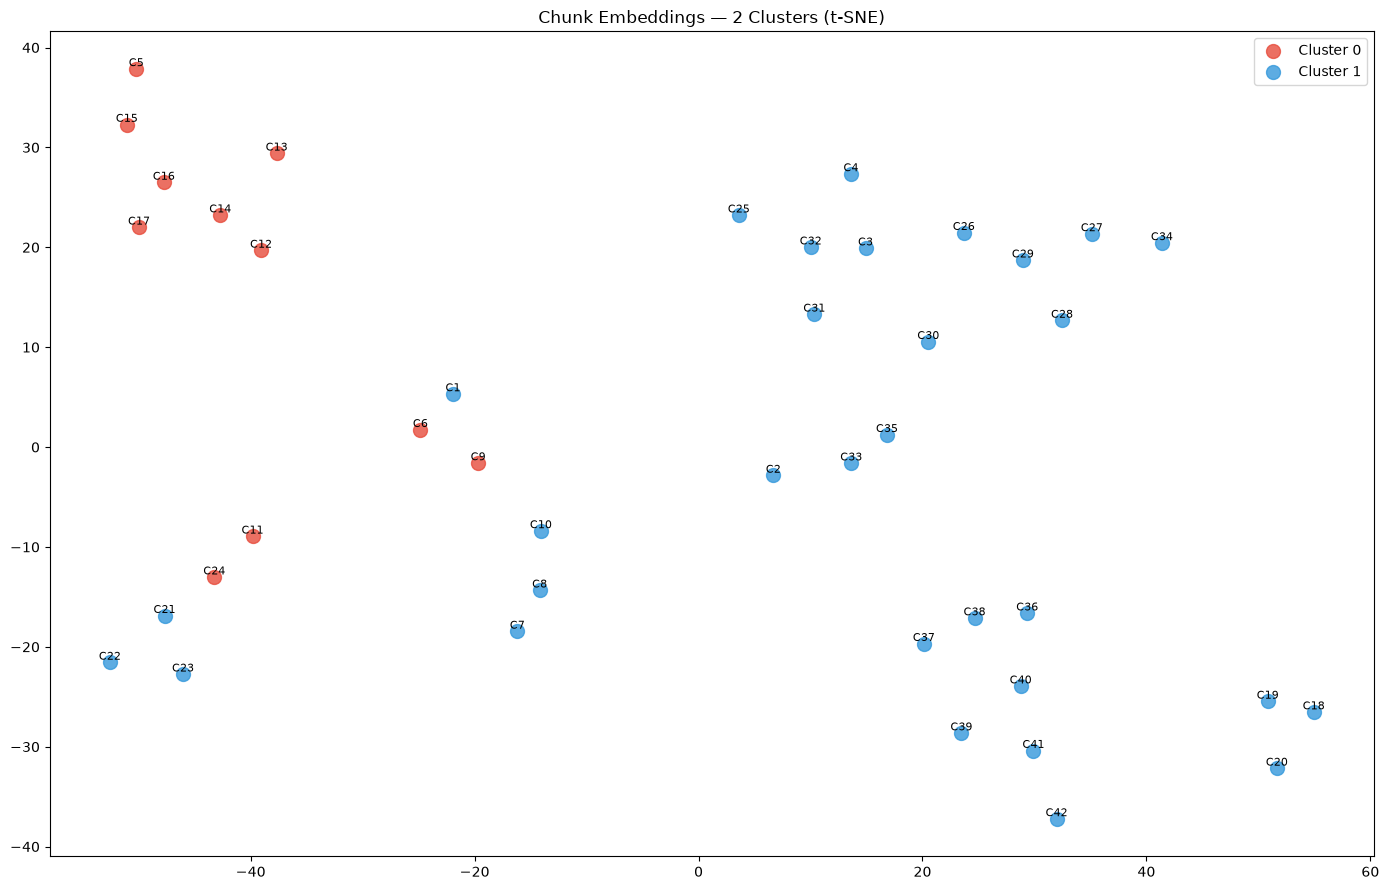

Cluster 0: Chunks [5, 6, 9, 11, 12, 13, 14, 15, 16, 17, 24]
Cluster 1: Chunks [1, 2, 3, 4, 7, 8, 10, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]


In [198]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

client = OpenAI(api_key=OPENAI_API_KEY)

# 1. Generate embeddings for each chunk
def get_embedding(text):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    return response.data[0].embedding

print("Generating embeddings...")
embeddings = [get_embedding(chunk) for chunk in chunks]
embeddings_array = np.array(embeddings)
print(f"Generated {len(embeddings)} embeddings of dimension {embeddings_array.shape[1]}")

# 2. Identify 2 clusters using KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_array)

# 3. Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_array)

# 4. Plot with 2 colors based on cluster
colors = ['#e74c3c', '#3498db']  # red and blue
cluster_names = ['Cluster 0', 'Cluster 1']

plt.figure(figsize=(14, 9))
for cluster_id in range(2):
    mask = cluster_labels == cluster_id
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        alpha=0.8,
        s=100
    )

# Label each point with its chunk number
for i, (x, y) in enumerate(embeddings_2d):
    plt.annotate(f"C{i+1}", (x, y), fontsize=8, ha='center', va='bottom')

plt.title("Chunk Embeddings — 2 Clusters (t-SNE)")
plt.legend()
plt.tight_layout()
plt.show()

# Print which chunks belong to each cluster
for cluster_id in range(2):
    indices = [i+1 for i, l in enumerate(cluster_labels) if l == cluster_id]
    print(f"Cluster {cluster_id}: Chunks {indices}")

In [ ]:
#Initialize ChromaDb and Store Vectors
#initialize chromadb client(Persitent storage)
chroma_client= chromadb.PersistentClient(path="./chroma_db_twin")

#Chromadd client(in-memorty storage)
collection = chroma_client.get_or_create_collection(name="DigitalTwin")

#Empty the collection before adding new data(
if collection.get()["ids"]:
   collection.delete(collection.get()["ids"])

pprint(collection.get())


{'data': None,
 'documents': [],
 'embeddings': None,
 'ids': [],
 'included': ['metadatas', 'documents'],
 'metadatas': [],
 'uris': None}


In [200]:
collection.add(
    ids=ids,
    embeddings=embeddings,
    documents=chunks,
    metadatas=metadatas
)

pprint(collection.get())


{'data': None,
 'documents': ['\n'
               'VT is a Technical Program Manager with a passion for AI and '
               'machine learning. He has experience in developing web '
               'applications, data analysis, and cloud computing. VT enjoys '
               'solving complex problems and is always eager to learn new '
               'technologies. ',
               'er to learn new technologies. In his free time, he likes to '
               'read about the latest advancements in AI.\n'
               '\n'
               'Other Career History:\n'
               '2004- 2020: Worked for multiple companies in the IT sector and '
               'mainly on Microsoft Projects and Technologies. ',
               'ft Projects and Technologies. He has experience leading teams '
               'and managin projects in fact-pacing environment\n'
               '2020- present: VT has been working as Technical Program '
               'Manager at Princess cruises as a contractor.

In [211]:
#Test retrieval

test_query="university"

#Mebed the query using the same model we used for the chunks

response=client.embeddings.create(
    model="text-embedding-3-small",
    input=[test_query]
)

query_embedding=response.data[0].embedding

#Search ChromaDB
results= collection.query(
    query_embeddings=[query_embedding],
    n_results=3
)

print(f"***Query: {test_query}\n")
print("****Retrieved chunks")
for a,b in zip(results["documents"][0], results["metadatas"][0]):
    print(f"<<Document: {b['source']} --- Chunk {b['chunk_index']}>> \n{a} \n")

***Query: university

****Retrieved chunks
<<Document: Education --- Chunk 3>> 
accepted by the university. 

Vinayaka Mission's Research Foundation - University logo
Vinayaka Mission's Research Foundation - University

MCA, Computer Applications

2003 – 2006

Osmania University logo
Osmania University

BCA, Computer Applications

2000 – 2003 

<<Document: Education --- Chunk 2>> 
nalysis of practical problems in project appraisal/feasibility, apart from management of finance, marketing and human resources.

The project work "uTrash- The complete waste management service" was also accepted by the university. 

 

<<Document: Education --- Chunk 0>> 

University of Hyderabad logo
University of Hyderabad

Post Graduate Diploma in Project Management, Project Management

2015 – 2016

The course was designed to provide the most refined skills in understanding economic aspects of planning coupled with managerial aspects.  



Step 4: Dynamic Context Injection

In [212]:
tools=[]

In [ ]:
#Add tool calling functionality(PushOver)

#Set up Pushover
pushover_user=os.getenv("PUSHOVER_USER")
pushover_token=os.getenv("PUSHOVER_TOKEN")
pushover_url="https://api.pushover.net/1/messages.json"

#print(pushover_user)
#print(pushover_token)

#Create send_Notification function


def send_notification(message:str):
    payload={"user":pushover_user,"token":pushover_token,"message":message}
    requests.post(pushover_url,data=payload)

#Step3: Describe Pushover as an LLM tool

send_notification_function={
    "name": "send_notification",
    "description": "Sends a push notification to the real world version of you via Pushover mobile. Use this if the user need to alert the real-world version of you about important events, completed tasks, or time-sentive information.",
    "parameters": {
        "type":"object",
        "properties":{
            "message":{
                "type":"string",
                "description":"The notification message to send to the user's device"
            }
        },
        "required":["message"]
    }
    
    }
tools.append({"type":"function","function":send_notification_function})

#Test the notification function
#send_notification("Hello from the function calling test")

In [ ]:
# Create new dice roll function, describe it, add it to the list of tools


#simulates rolling a six-side die

def dice_roll():
    result = random.randint(1,6)
    return result
#Describe function schema 

roll_dice_function={
"name": "dice_roll",
    "description": "Simulates rolling a single six-side dice. Use this to get a random dice roll.",
    "parameters": {
        "type":"object",
        "properties":{},
        "required":[]
    }

}

#Add function to the list of LLM
tools.append({"type":"function","function":roll_dice_function})

In [137]:
#Function to handle LLM tool calls 
def handle_tool_call(tool_calls):
    tool_results=[]
    
    for tool_call in tool_calls:
        function_name = tool_call.function.name
        args= json.loads(tool_call.function.arguments)

        if function_name=="send_notification":
        #Send the notification, i.e. call the tool
            send_notification(args["message"])
            content=f" Notification Sent: {args['message']}"
        elif function_name == "dice_roll":
             content=f"Rolled {dice_roll()}"
        #elif function_name="Insert_function-3":
           # content=Insert_function-3{args["message"]}"

        else:
            content = f"unknown function: {function_name}"

   # print(f"sent notification: {args['message']}")
        tool_call_result={
            "role":"tool",
            "content": content,
            "tool_call_id":tool_call.id
        }
        tool_results.append(tool_call_result)
    return tool_results

#Function to process the conversation turn

In [138]:
system_message="You are a helpful assistant that answers based on relevant information. If you do not know the answer, say you do not know. Important: Do not hallicunate and only use information in the context and if you dont know the context, say you dont know."



In [ ]:
def respond_ai(message,history):
  #RAG
    response= client.embeddings.create(
        model="text-embedding-3-small",
        input=[message]
 )

    query_embedding=response.data[0].embedding

    #search ChromaDB
    results=collection.query(
        query_embeddings=[query_embedding],
        n_results=3
    )

#stitch retrived chunks together to create the context for the response
    context="\n---\n".join(results["documents"][0])
    print("\n====================================\n")
    print(f"User message:\n{message}\n")
    print("****Retrieved chunks")
    for a,b in zip(results["documents"][0], results["metadatas"][0]):
        print("-----------------------")
        print(f"<<Document: {b['source']} --- Chunk {b['chunk_index']}>> \n{a} \n")

    system_message_enhanced= system_message+"\n\nContext:\n"+context
#As usual 
    messages= [{"role":"system","content": system_message_enhanced}] + history + [{"role":"user","content": message}]
    print("System Message Enhanced: ", system_message_enhanced) # Debugging line to check the enhanced system message
   # client=OpenAI(api_key=OPENAI_API_KEY) 
    response=client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )
    
    #Check if model wants to call a tool
    message=response.choices[0].message
    while message.tool_calls:
        pprint(message.tool_calls)
        tool_result = handle_tool_call(message.tool_calls) #whole list of tool calls on purpose
        messages.append(message)  #....add message to context, i.e message
        messages.extend(tool_result) #.... add info about tool call response to "context", i.e messages change from append to extend for multiple tool calks
     #... invoke the LLM one more time to get its updated response
        response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=messages,
        tools=tools
    )
    
 #print(message.content)    #.. print(message.content)
        message=response.choices[0].message
 
    return (message.content)
  



#Launch Gradio

In [214]:
gr.ChatInterface(fn=respond_ai, title="VT's chatbot", description="Know more about VT!").launch(inbrowser=True)


* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


/Users/varghesethomas/Personal/Learning/AI_Engineering/ai_env/lib/python3.13/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)




User message:
Hi there

****Retrieved chunks
-----------------------
<<Document: Professional experience --- Chunk 15>> 
008 - Jun 2013 · 5 yrs 6 mos

Redmond, Washington

Worked with external and internal partners, 
Driver content authoring & WU detection Logic for in-house projects.
Debug/triage WU driver install issues
Mark drivers as Important on WU.

 

-----------------------
<<Document: Professional experience --- Chunk 14>> 
er not found (DNF) responses.
•	Involved in driver servicing for system-on-chip (SoC) partners. 
•	Conducted stakeholder reviews for device driver removals from Windows Update.
… more

Wipro Limited logo
Solution Delivery Analyst

Wipro Limited · Full-time

Jan 2008 - Jun 2013 · 5 yrs 6 mos

 

-----------------------
<<Document: Professional experience --- Chunk 13>> 


Robustware INC · Full-time

Jul 2013 - Jun 2016 · 3 yrs

Redmond

Planning of resources, schedules for the publishing teams(s). 
•	Program delivery and spec review for Publishing & Model 

/Users/varghesethomas/Personal/Learning/AI_Engineering/ai_env/lib/python3.13/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/varghesethomas/Personal/Learning/AI_Engineering/ai_env/lib/python3.13/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)




User message:
what can you tell about your experience or knowledge of accounting

****Retrieved chunks
-----------------------
<<Document: Overview --- Chunk 8>> 
ement and knowledge sharing.

Communication Style: VT is known for his clear and concise communication style. He is able to convey complex technical concepts in a way that is easily understandable to both technical and non-technical stakeholders.  

-----------------------
<<Document: Education --- Chunk 2>> 
nalysis of practical problems in project appraisal/feasibility, apart from management of finance, marketing and human resources.

The project work "uTrash- The complete waste management service" was also accepted by the university. 

 

-----------------------
<<Document: Overview --- Chunk 1>> 
er to learn new technologies. In his free time, he likes to read about the latest advancements in AI.

Other Career History:
2004- 2020: Worked for multiple companies in the IT sector and mainly on Microsoft Projects and Techno

/Users/varghesethomas/Personal/Learning/AI_Engineering/ai_env/lib/python3.13/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/varghesethomas/Personal/Learning/AI_Engineering/ai_env/lib/python3.13/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)




User message:
what can you tell about computer technology?

****Retrieved chunks
-----------------------
<<Document: Overview --- Chunk 1>> 
er to learn new technologies. In his free time, he likes to read about the latest advancements in AI.

Other Career History:
2004- 2020: Worked for multiple companies in the IT sector and mainly on Microsoft Projects and Technologies.  

-----------------------
<<Document: Overview --- Chunk 0>> 

VT is a Technical Program Manager with a passion for AI and machine learning. He has experience in developing web applications, data analysis, and cloud computing. VT enjoys solving complex problems and is always eager to learn new technologies.  

-----------------------
<<Document: Professional experience --- Chunk 5>> 
sture at the executive level.
•Consistently exceed customer satisfaction targets through delivery of impactful enhancements and automation that measurably reduce operational overhead.… more

 Technical Project Leadership and Technolog

/Users/varghesethomas/Personal/Learning/AI_Engineering/ai_env/lib/python3.13/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


In [87]:
#Set up Pushover
pushover_user=os.getenv("PUSHOVER_USER")
pushover_token=os.getenv("PUSHOVER_TOKEN")
pushover_url="https://api.pushover.net/1/messages.json"

import requests

def send_notification(message:str):
    payload={"user":pushover_user,"token":pushover_token,"message":message}
    requests.post(pushover_url,data=payload)

#Step3: Describe Pushover as an LLM tool

send_notification_function={
    "name": "send_notification",
    "description": "Sends a push notification to the users phone via Pushover. Use this to alert the user about the important events, completed tasks, or time-sentive information.",
    "parameters": {
        "type":"object",
        "properties":{
            "message":{
                "type":"string",
                "description":"The notification message to send to the user's device"
            }
        },
        "required":["message"]
    }
    
    }